## Model 2 Faulted model
- This is a simple faulted model to show how to model fault in GeoINR

In [1]:
import geoinr_faults as grf

Define the model conditions

In [2]:
geomodel = grf.create_geomodel(
    project_name='Amoco',
    extent=[0, 1000, 0, 1000, 0, 1000],
    resolution=[200, 200, 200],
    path_to_surface_points='input_data/Faulted_model/faulted_interface.csv',
    path_to_orientations='input_data/Faulted_model/faulted_orientation.csv',
)

In [3]:
geomodel

GeoModel('Amoco', extent=[0, 1000, 0, 1000, 0, 1000], resolution=[200, 200, 200], stratis=0, horizons=[], faults=0)

Add stratigraphy column

In [4]:
geomodel = grf.add_stratis(geomodel, strati_configs=[
    grf.StratiConfig(name="layer_cake", formations=['rock2', 
                                                  'rock1']),
])

In [5]:
geomodel

GeoModel('Amoco', extent=[0, 1000, 0, 1000, 0, 1000], resolution=[200, 200, 200], stratis=1, horizons=[2], faults=0)

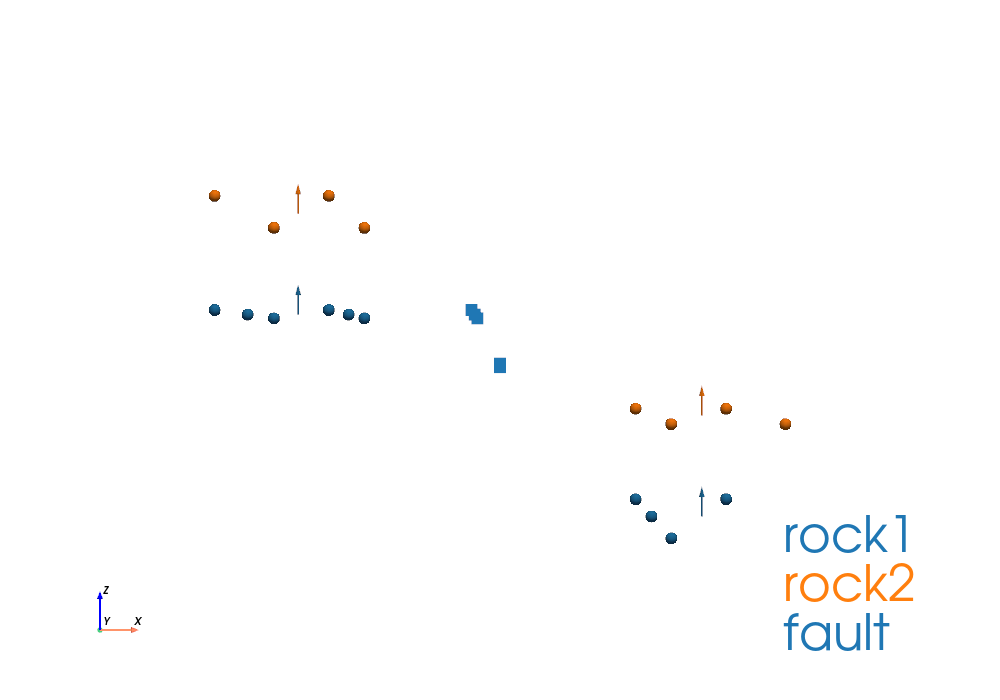

In [6]:
grf.plot_input_data(geomodel, notebook=True, legend_size=(0.22, 0.22))

Add faults, here the fault trunction rules are used, if `truncation` is true, need to define the truncting fault

In [7]:
geomodel = grf.add_faults(geomodel, fault_configs=[
    grf.FaultConfig(name='fault', lx=10000, ly=10000, lz=10000, # set large to mimic infinite extent
                   dmax=1, lam=0.5, Normal_fault=True),
])

In [8]:
geomodel

GeoModel('Amoco', extent=[0, 1000, 0, 1000, 0, 1000], resolution=[200, 200, 200], stratis=1, horizons=[2], faults=1)

Visualization of fault feature fields

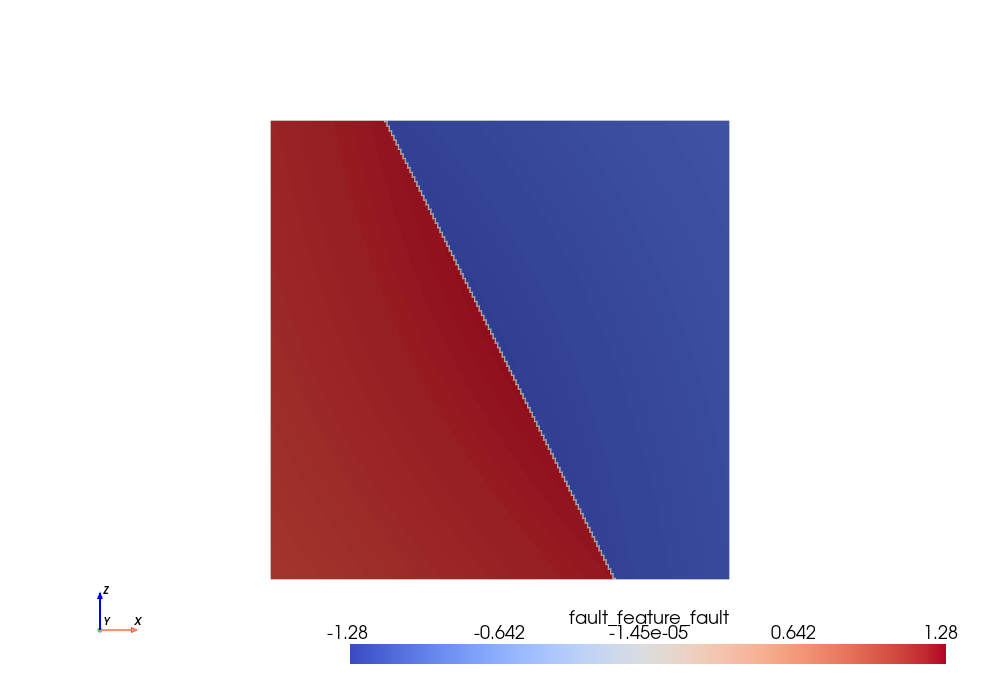

In [9]:
grf.plot_fault_features(geomodel, fault_name='fault', cmap='coolwarm', notebook=True)

Visualizing fault surfaces

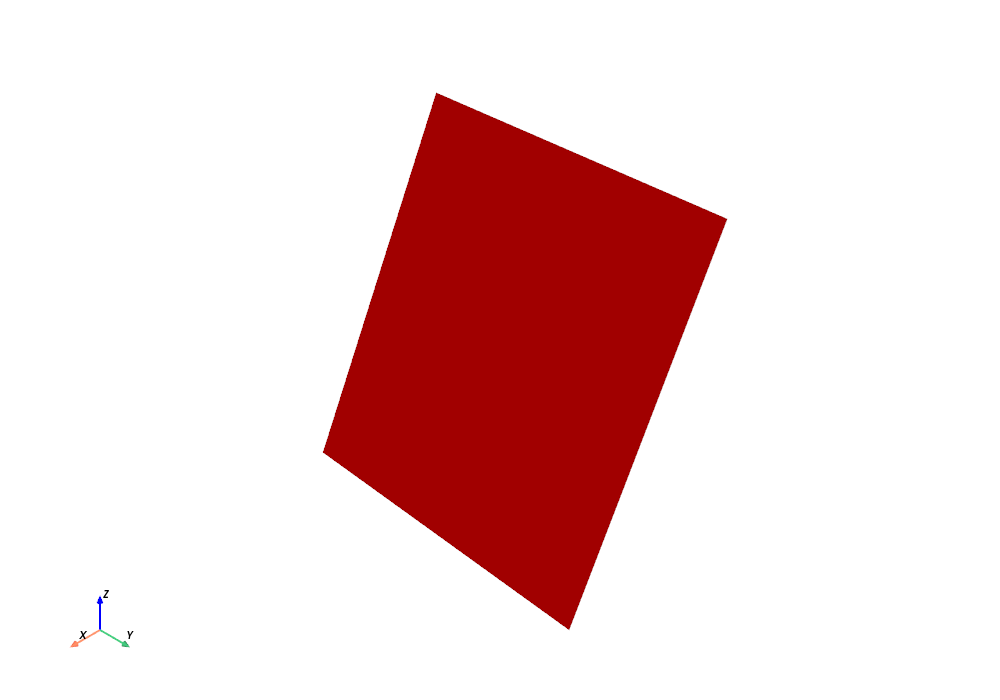

In [10]:
grf.plot_fault_meshes(geomodel, notebook=True, camera_position=[2000, 2000, 2000])

Compute model

In [11]:
results = grf.compute_model(
    geomodel,
    nn_model='mlp',          # 'mlp' | 'siren' | 'resnet'  or custom class
    hidden_dim=128,
    n_layers=3,
    activation='softplus',   # 'softplus' | 'relu' | 'tanh' | 'sine' | ...
    softplus_beta=1,
    epochs=1000,
    lr=1e-3,
    seed=0,
)

Epoch [500/1000]  Loss: 0.0248  Var: 0.0000  On: 0.0235  Above: 0.0000  Below: 0.0000  Orie: 0.0013  Best: 0.0047
Epoch [1000/1000]  Loss: 0.0078  Var: 0.0000  On: 0.0070  Above: 0.0000  Below: 0.0000  Orie: 0.0008  Best: 0.0036

Training finished in 5.2 s  |  Best loss: 0.0036
Inference completed in 0.2523 s


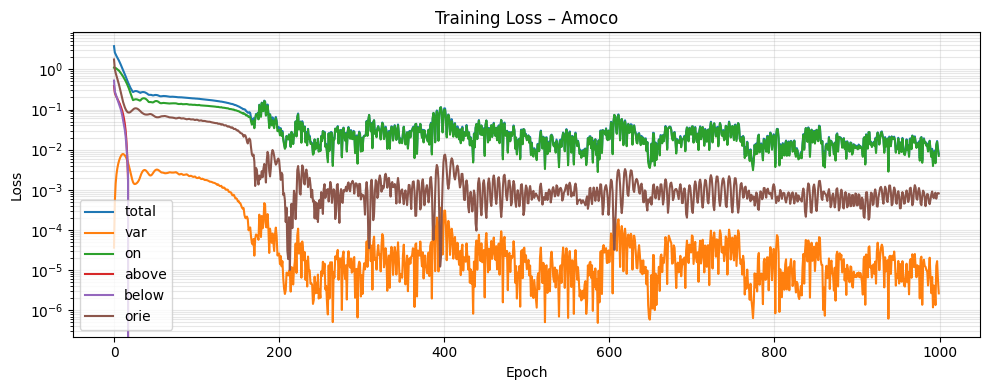

In [12]:
grf.plot_loss(results)

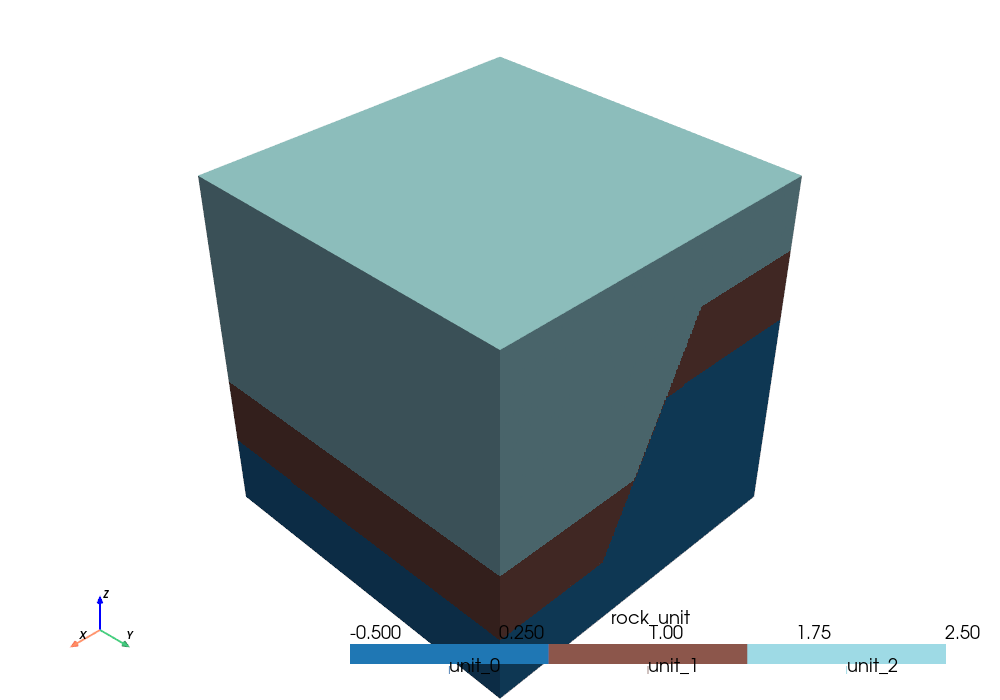

In [13]:
grf.plot_model(results, notebook=True, show_scalar_field=False, show_isosurfaces=False, show_rock_unit=True)

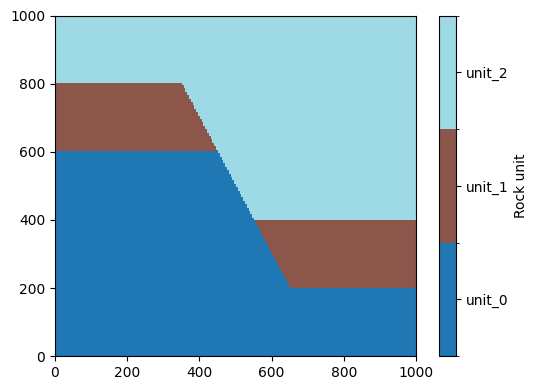

In [14]:
grf.plot_section_rock_unit(results, axis='y',figsize=(5.5, 4))